Target state  |->  =  (|0> - |1>)/sqrt(2)
Target amplitudes: [ 0.70711 -0.70711]

Resulting Statevector:
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))

Individual Amplitudes:
  State |0> : amplitude = +0.7071+0.0000j, probability = 0.5000
  State |1> : amplitude = -0.7071+0.0000j, probability = 0.5000

Absolute Numerical Difference vs target: 0.00000000e+00
STATUS: SUCCESS - the circuit produces exactly |->.

--- Experimental Verification (Aer simulator, 4096 shots) ---
(a) Z-basis counts : {'1': 2018, '0': 2078}
    -> P(0) = 0.5073, P(1) = 0.4927   (expected ~0.50 / 0.50)

(b) X-basis counts : {'1': 4096}
    -> P(1) = 1.0000   (expected 1.00 for |->, 0.00 for |+>)

--- Final Verdict ---
STATUS: SUCCESS - X-basis measurement returns '1' every time,
which experimentally confirms the state is |-> and not |+>.

--- Quantum Circuit (state preparation) ---


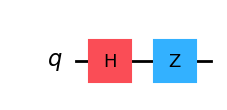

--- Quantum Circuit (X-basis measurement) ---


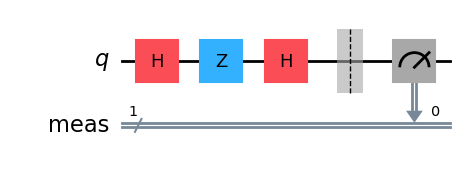

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

# ==============================================================
# WEEK 3 - MEDIUM
# Combine the H and Z gates to construct the |-> state and
# verify it experimentally through simulation.
#
#   |0>  --H-->  |+> = (|0> + |1>)/sqrt(2)
#   |+>  --Z-->  |-> = (|0> - |1>)/sqrt(2)
# So the correct order is H first, then Z.
# ==============================================================

qc = QuantumCircuit(1)
qc.h(0)   # step 1: |0>  ->  |+>
qc.z(0)   # step 2: |+>  ->  |->

# ---------------- 1. Theoretical target ---------------------------
target = np.array([1 / np.sqrt(2), -1 / np.sqrt(2)])
print("Target state  |->  =  (|0> - |1>)/sqrt(2)")
print("Target amplitudes:", np.round(target, 5))

# ---------------- 2. Statevector produced by the circuit ----------
state = Statevector.from_instruction(qc)
print("\nResulting Statevector:")
print(state)

print("\nIndividual Amplitudes:")
for idx, amp in enumerate(state.data):
    print(f"  State |{idx}> : amplitude = {amp:+.4f}, "
          f"probability = {abs(amp) ** 2:.4f}")

max_diff = np.max(np.abs(state.data - target))
print(f"\nAbsolute Numerical Difference vs target: {max_diff:.8e}")
print("STATUS: SUCCESS - the circuit produces exactly |->."
      if np.isclose(max_diff, 0.0, atol=1e-9)
      else "STATUS: FAILED - state does not match |->.")

# ---------------- 3. Experimental verification --------------------
# A Z-basis measurement CANNOT distinguish |+> from |-> : both give
# 50/50. To prove we really have |->, we measure in the X basis by
# applying one more H before measuring:
#        H|-> = |1>   ->  we must see '1' essentially 100% of the time
#        H|+> = |0>   ->  would give '0' 100% of the time
sim = AerSimulator()
SHOTS = 4096

# (a) Z-basis measurement -> expect ~50/50
qc_z = qc.copy()
qc_z.measure_all()
counts_z = sim.run(qc_z, shots=SHOTS).result().get_counts()

# (b) X-basis measurement -> expect ~100% '1'
qc_x = qc.copy()
qc_x.h(0)          # rotate X basis into Z basis
qc_x.measure_all()
counts_x = sim.run(qc_x, shots=SHOTS).result().get_counts()

print("\n--- Experimental Verification (Aer simulator, "
      f"{SHOTS} shots) ---")
print(f"(a) Z-basis counts : {counts_z}")
print(f"    -> P(0) = {counts_z.get('0', 0) / SHOTS:.4f}, "
      f"P(1) = {counts_z.get('1', 0) / SHOTS:.4f}   (expected ~0.50 / 0.50)")

frac_one = counts_x.get("1", 0) / SHOTS
print(f"\n(b) X-basis counts : {counts_x}")
print(f"    -> P(1) = {frac_one:.4f}   (expected 1.00 for |->, "
      f"0.00 for |+>)")

print("\n--- Final Verdict ---")
if frac_one > 0.99:
    print("STATUS: SUCCESS - X-basis measurement returns '1' every time,")
    print("which experimentally confirms the state is |-> and not |+>.")
else:
    print("STATUS: FAILED - state is not |->.")

# ---------------- 4. Circuit diagrams -----------------------------
print("\n--- Quantum Circuit (state preparation) ---")
display(qc.draw(output="mpl", style="iqp"))

print("--- Quantum Circuit (X-basis measurement) ---")
display(qc_x.draw(output="mpl", style="iqp"))